# Example notebook: ray shooting and PSF convolution

`pipeline_walkthrough.ipynb` builds a `SyntheticImage` in a single constructor call. This
notebook opens that call up. It covers, in order:

- **§2 Ray shooting** — how `lenstronomy` turns a mass model and two light models into a
  surface brightness field.
- **§3 The pixel grid** — where mejiro puts pixels, and what "centred on the deflector" costs
  later on.
- **§4 Supersampling** — `kwargs_numerics`, and why the surface brightness is evaluated on a
  grid finer than the one it is stored on.
- **§5 The PSF** — the STPSF kernel, how undersampled Roman is, and how the kernel varies
  across a detector.
- **§6 The detector pixel response** — the reason mejiro renders at `pixel_scale / oversample`
  instead of at the detector pixel scale, and what went wrong when it did not.
- **§7 `bin_to_native`** — the operator that applies the pixel integral, at a chosen sub-pixel
  phase, and why the phase cannot be applied at detector resolution.
- **§8 Choosing `supersampling_factor`** — a convergence study, measured against the
  substructure signal it has to stay below.

The companion notebook `l2_l3_with_romanisim.ipynb` picks up where this one stops: it takes
the oversampled surface brightness produced here and turns it into L2 exposures with
romanisim and an L3 mosaic with romancal.

Background reading, all in `docs/`:
[step04_oversampled_rendering.md](../docs/step04_oversampled_rendering.md),
[subpixel_phase.md](../docs/subpixel_phase.md),
[l3_dither_registration.md](../docs/l3_dither_registration.md).

In [6]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, SymLogNorm

import mejiro
from mejiro.galaxy_galaxy import SampleGG
from mejiro.instruments.roman import Roman
from mejiro.pipeline._05_romanisim import bin_to_native, subpixel_phase
from mejiro.synthetic_image import SyntheticImage
from mejiro.utils import lenstronomy_util, util

plt.rcParams['image.origin'] = 'lower'

# where the checked-in STPSF kernels live, so this notebook runs without an STPSF install
TEST_DATA = os.path.join(os.path.dirname(mejiro.__path__[0]), 'tests', 'test_data')

## 1. Setup

One lens, one instrument, one band. `SampleGG` is a singly-imaged-source SIE + shear system
drawn from SLSim; it is smooth and analytic, which makes it a good first example and a poor
stress test — we add pyHalo substructure in section 8 for the parts that need it.

In [2]:
strong_lens = SampleGG()
roman = Roman()
band = 'F129'

# detector and position pinned: the Roman PSF is field-dependent, so every comparison in this
# notebook has to hold them fixed or it is comparing PSFs rather than the thing it means to
instrument_params = {'detector': 1, 'detector_position': (2048, 2048)}

pixel_scale = roman.get_pixel_scale(band).value
print(f'{roman.name} {band}: pixel scale {pixel_scale} arcsec/px')
print(f'lens: {strong_lens.name}, z_l = {strong_lens.z_lens:.3f}, z_s = {strong_lens.z_source:.3f}, '
      f'theta_E = {strong_lens.get_einstein_radius():.3f} arcsec')
print(f'mass model: {strong_lens.lens_model_list}')
print(f'light models: lens {strong_lens.kwargs_model["lens_light_model_list"]}, '
      f'source {strong_lens.kwargs_model["source_light_model_list"]}')

Roman F129: pixel scale 0.11 arcsec/px
lens: SampleGG, z_l = 0.290, z_s = 0.588, theta_E = 1.168 arcsec
mass model: ['SIE', 'SHEAR', 'CONVERGENCE']
light models: lens ['SERSIC_ELLIPSE'], source ['SERSIC_ELLIPSE']


The PSF is a pixel kernel from [STPSF](https://stpsf.readthedocs.io), computed at 5x the
detector pixel scale on a 101x101 detector-pixel support (so 505x505 samples at
0.022 arcsec/px). The pipeline caches these per (band, detector, position, oversample, size)
under `psf_cache_dir`; here we load one that ships with the test suite.

The live equivalent is
`roman.get_psf_kwargs(band, detector, detector_position, oversample=5, num_pix=101)`, or
`STPSFEngine.get_roman_psf(...)` for the bare array.

kernel: (505, 505) samples at 0.0220 arcsec/px = 101 detector px across
sums to 0.9886


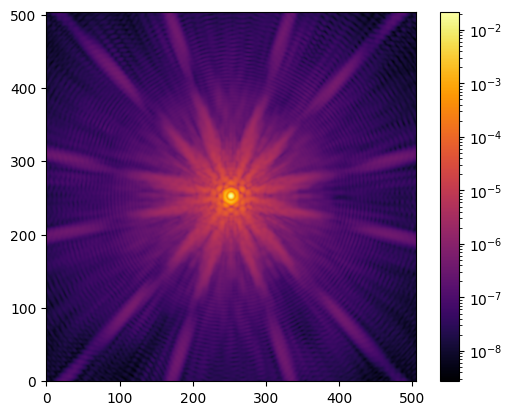

In [7]:
kernel = np.load(os.path.join(TEST_DATA, f'{band}_1_2048_2048_5_101.npy'))
psf_oversample = 5

print(f'kernel: {kernel.shape} samples at {pixel_scale / psf_oversample:.4f} arcsec/px '
      f'= {kernel.shape[0] / psf_oversample:.0f} detector px across')
print(f'sums to {kernel.sum():.4f}')

plt.imshow(kernel, norm=LogNorm(), cmap='inferno')
plt.colorbar()
plt.show()

Build the image the way the production config does: on a grid five times finer than the
detector, with the kernel used at its own resolution. Sections 5 and 6 are about why.

2026-07-29 14:25:32 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix
2026-07-29 14:25:32 INFO     Synthetic image calculation time: 0.546 s


rendered grid:  235 px at 0.0220 arcsec/px
detector grid:  47 px at 0.1100 arcsec/px
field of view:  5.1700 arcsec
total flux:     4223.49 counts/sec


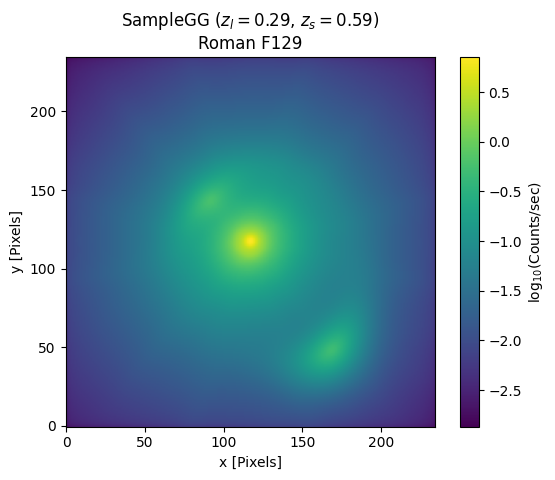

In [9]:
fov_arcsec = 5.0
oversample = 5

kwargs_psf = lenstronomy_util.get_pixel_psf_kwargs(kernel, psf_oversample, degrade=False)
kwargs_numerics = {'supersampling_factor': 3, 'compute_mode': 'regular'}

synthetic_image = SyntheticImage(strong_lens,
                                 instrument=roman,
                                 band=band,
                                 fov_arcsec=fov_arcsec,
                                 instrument_params=instrument_params,
                                 kwargs_numerics=kwargs_numerics,
                                 kwargs_psf=kwargs_psf,
                                 pieces=True,
                                 oversample=oversample)

print(f'rendered grid:  {synthetic_image.num_pix} px at {synthetic_image.pixel_scale:.4f} arcsec/px')
print(f'detector grid:  {synthetic_image.native_num_pix} px at {synthetic_image.native_pixel_scale:.4f} arcsec/px')
print(f'field of view:  {synthetic_image.fov_arcsec:.4f} arcsec')
print(f'total flux:     {synthetic_image.get_flux():.2f} counts/sec')

synthetic_image.plot()

Constructing the `SyntheticImage` has a side effect worth knowing about: it converts the
lens and source **magnitudes** into lenstronomy **amplitudes** in place on the `StrongLens`,
using the SCA-specific zero point. Everything below reads those amplitudes, which is why
this cell comes first.

In [10]:
def scalar(x):
    """Roman's zero point and lenstronomy's amplitudes both arrive as length-1 astropy
    Columns; everything below wants a plain float."""
    return float(np.asarray(x).ravel()[0])


print(f'zero point (SCA {instrument_params["detector"]:02d}, {band}): '
      f'{scalar(synthetic_image.magnitude_zeropoint):.4f} AB mag')
print(f'source amp:      {scalar(strong_lens.kwargs_source[0]["amp"]):.4f}')
print(f'lens light amp:  {scalar(strong_lens.kwargs_lens_light[0]["amp"]):.4f}')

zero point (SCA 01, F129): 26.3194 AB mag
source amp:      375.0546
lens light amp:  636.4165


## 2. Ray shooting

The lens equation maps an image-plane position $\theta$ to the source-plane position
$\beta$ it sees:

$$\beta = \theta - \alpha(\theta)$$

where $\alpha$ is the scaled deflection of the mass model. `lenstronomy` evaluates it with
`LensModel.ray_shooting(x, y, kwargs_lens)`. When the mass model spans more than one
redshift — which is what happens as soon as pyHalo line-of-sight halos are added — the same
call does the full multi-plane recursion instead, so nothing downstream has to know.

The image is then

$$I(\theta) = \underbrace{I_{s}\big(\beta(\theta)\big)}_{\text{lensed source}}
            + \underbrace{I_{l}(\theta)}_{\text{deflector light}}$$

convolved with the PSF. The deflector light is *not* ray-shot: it sits in the image plane
already. `SyntheticImage(pieces=True)` keeps the two terms separately, which is what the
next figures use.

In [11]:
lens_model = strong_lens.lens_model

# a regular grid in angular coordinates, independent of the image pixel grid
half = synthetic_image.fov_arcsec / 2
grid = np.linspace(-half, half, 400)
theta_x, theta_y = np.meshgrid(grid, grid)

alpha_x, alpha_y = lens_model.alpha(theta_x, theta_y, strong_lens.kwargs_lens)
beta_x, beta_y = lens_model.ray_shooting(theta_x, theta_y, strong_lens.kwargs_lens)
magnification = lens_model.magnification(theta_x, theta_y, strong_lens.kwargs_lens)

# the deflection is what turns theta into beta; check the identity holds
assert np.allclose(beta_x, theta_x - alpha_x)

# for an isothermal profile the deflection is constant and equal to theta_E; the full model
# also carries external shear and a convergence sheet, so the total is close but not equal
from lenstronomy.LensModel.lens_model import LensModel

sie_only = LensModel(['SIE'])
theta_E = strong_lens.get_einstein_radius()
print(f'|alpha| at theta_E = {theta_E:.3f} arcsec')
print(f'  SIE alone:  {np.hypot(*sie_only.alpha(theta_E, 0.0, strong_lens.kwargs_lens[:1])):.3f} arcsec')
print(f'  full model: {np.hypot(*lens_model.alpha(theta_E, 0.0, strong_lens.kwargs_lens)):.3f} arcsec '
      f'(SIE + shear + convergence)')

|alpha| at theta_E = 1.168 arcsec
  SIE alone:  1.166 arcsec
  full model: 1.197 arcsec (SIE + shear + convergence)


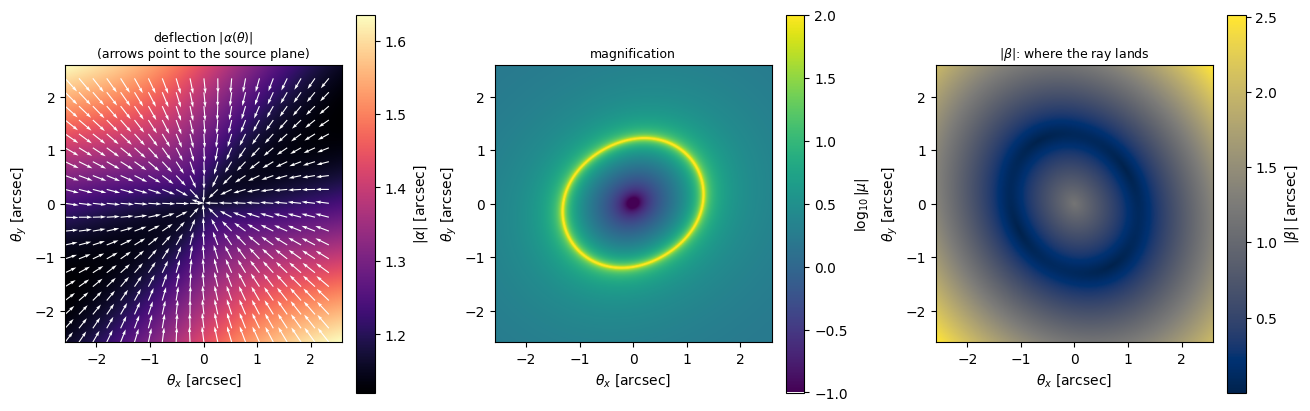

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
extent = [-half, half, -half, half]

im = axes[0].imshow(np.hypot(alpha_x, alpha_y), extent=extent, cmap='magma')
step = 20
axes[0].quiver(theta_x[::step, ::step], theta_y[::step, ::step],
               -alpha_x[::step, ::step], -alpha_y[::step, ::step],
               color='white', scale=25, width=0.004)
plt.colorbar(im, ax=axes[0], label=r'$|\alpha|$ [arcsec]')
axes[0].set_title(r'deflection $|\alpha(\theta)|$' + '\n(arrows point to the source plane)', fontsize=9)

im = axes[1].imshow(np.log10(np.abs(magnification)), extent=extent, cmap='viridis', vmin=-1, vmax=2)
plt.colorbar(im, ax=axes[1], label=r'$\log_{10}|\mu|$')
axes[1].set_title('magnification', fontsize=9)

# where each image-plane point lands in the source plane
im = axes[2].imshow(np.hypot(beta_x, beta_y), extent=extent, cmap='cividis')
plt.colorbar(im, ax=axes[2], label=r'$|\beta|$ [arcsec]')
axes[2].set_title(r'$|\beta|$: where the ray lands', fontsize=9)

for ax in axes:
    ax.set_xlabel(r'$\theta_x$ [arcsec]')
    ax.set_ylabel(r'$\theta_y$ [arcsec]')
plt.show()

The dark ring in the magnification panel is the **critical curve**: where the lens mapping
is singular and $|\mu| \to \infty$. Its image in the source plane is the **caustic**. A
source inside the caustic is multiply imaged; outside it, singly imaged. That is the entire
reason these systems look the way they do, so it is worth drawing explicitly.

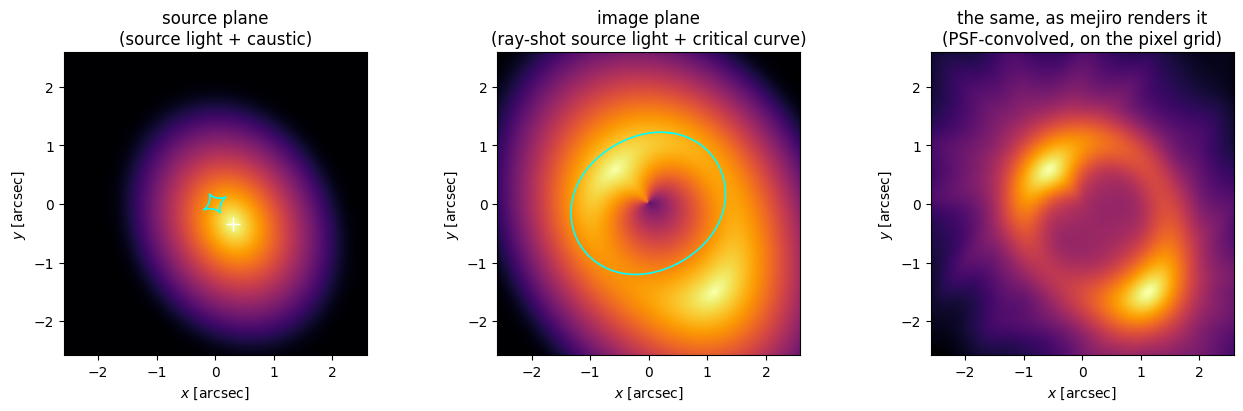

In [16]:
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions

ext = LensModelExtensions(lens_model)
ra_crit, dec_crit, ra_caus, dec_caus = ext.critical_curve_caustics(
    strong_lens.kwargs_lens, compute_window=synthetic_image.fov_arcsec, grid_scale=0.01)

source_kwargs = strong_lens.kwargs_source
source_center = (source_kwargs[0]['center_x'], source_kwargs[0]['center_y'])

# unlensed source: evaluate the source light directly on a source-plane grid
unlensed = strong_lens.source_light_model.surface_brightness(theta_x, theta_y, source_kwargs)
# lensed source: evaluate the same light model at the ray-shot positions
lensed = strong_lens.source_light_model.surface_brightness(beta_x, beta_y, source_kwargs)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

axes[0].imshow(np.log10(unlensed + 1e-6), extent=extent, cmap='inferno')
for x, y in zip(ra_caus, dec_caus):
    axes[0].plot(x, y, color='cyan', lw=1.2)
axes[0].plot(*source_center, marker='+', color='white', ms=10)
axes[0].set_title('source plane\n(source light + caustic)')

axes[1].imshow(np.log10(lensed + 1e-6), extent=extent, cmap='inferno')
for x, y in zip(ra_crit, dec_crit):
    axes[1].plot(x, y, color='cyan', lw=1.2)
axes[1].set_title('image plane\n(ray-shot source light + critical curve)')

axes[2].imshow(np.log10(synthetic_image.source_surface_brightness + 1e-6),
               extent=extent, cmap='inferno')
axes[2].set_title('the same, as mejiro renders it\n(PSF-convolved, on the pixel grid)')

for ax in axes:
    ax.set_xlabel(r'$x$ [arcsec]')
    ax.set_ylabel(r'$y$ [arcsec]')
plt.show()

The middle panel is the ray-shooting result in its rawest form: *the same source light
model, evaluated at deflected coordinates.* Everything else mejiro does to it is
bookkeeping — sampling, convolution, units.

A more literal picture of the mapping: take a coarse grid of image-plane points, colour them
by where they are, and plot them again at their ray-shot source-plane positions. The lens
folds the plane over onto itself, and the fold is the caustic.

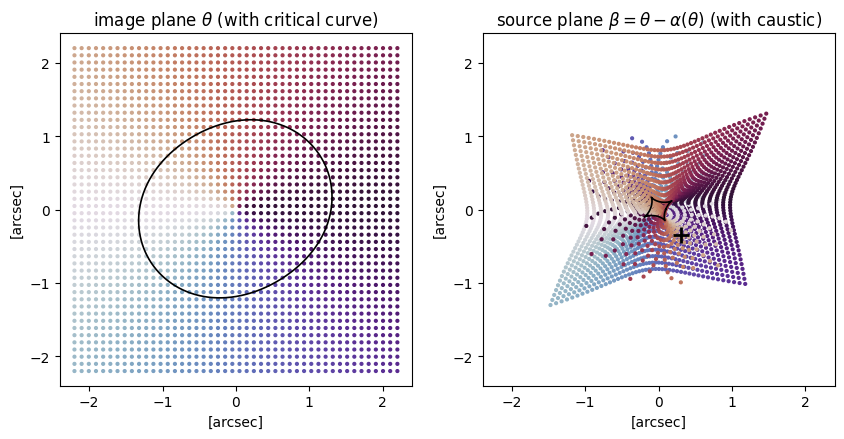

In [15]:
coarse = np.linspace(-2.2, 2.2, 46)
cx, cy = np.meshgrid(coarse, coarse)
bx, by = lens_model.ray_shooting(cx, cy, strong_lens.kwargs_lens)
colour = np.arctan2(cy, cx)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
axes[0].scatter(cx, cy, c=colour, s=4, cmap='twilight')
for x, y in zip(ra_crit, dec_crit):
    axes[0].plot(x, y, color='k', lw=1.2)
axes[0].set_title(r'image plane $\theta$ (with critical curve)')

axes[1].scatter(bx, by, c=colour, s=4, cmap='twilight')
for x, y in zip(ra_caus, dec_caus):
    axes[1].plot(x, y, color='k', lw=1.2)
axes[1].plot(*source_center, marker='+', color='k', ms=12, mew=2)
axes[1].set_title(r'source plane $\beta = \theta - \alpha(\theta)$ (with caustic)')

for ax in axes:
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.set_aspect('equal')
    ax.set_xlabel('[arcsec]')
    ax.set_ylabel('[arcsec]')
plt.show()

Note how the rays crowd towards the centre: a large area of the image plane maps into a
small area of the source plane near the caustic. That crowding *is* magnification, and it is
also why the arc is the hardest part of the image to sample — section 4.

The two light components mejiro keeps separately with `pieces=True`:

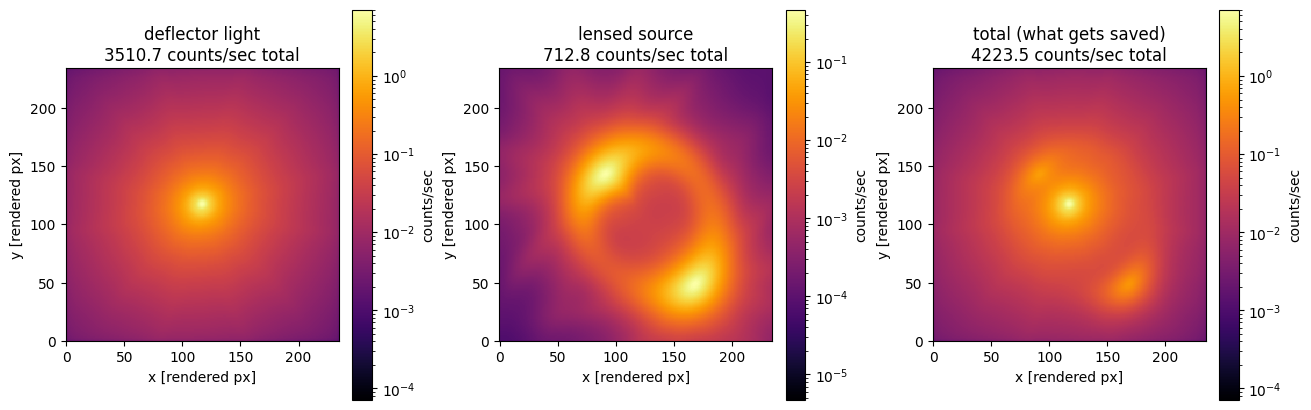

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pieces = [('deflector light', synthetic_image.lens_surface_brightness),
          ('lensed source', synthetic_image.source_surface_brightness),
          ('total (what gets saved)', synthetic_image.data)]
for ax, (title, arr) in zip(axes, pieces):
    im = ax.imshow(arr, norm=LogNorm(vmin=max(arr.max() * 1e-5, 1e-8), vmax=arr.max()), cmap='inferno')
    plt.colorbar(im, ax=ax, label='counts/sec')
    ax.set_title(f'{title}\n{arr.sum():.1f} counts/sec total')
    ax.set_xlabel('x [rendered px]')
    ax.set_ylabel('y [rendered px]')
plt.show()

## 3. The pixel grid

The grid is built in two steps, and the order matters:

```python
native_num_pix = util.set_odd_num_pix(fov_arcsec, native_pixel_scale)   # detector grid first
self.pixel_scale = native_pixel_scale / oversample                      # then subdivide
self.num_pix     = native_num_pix * oversample
```

Sizing directly at the fine scale does **not** give a multiple of the detector grid:
`set_odd_num_pix(10.01, 0.022)` is 457, whereas `5 * set_odd_num_pix(10.01, 0.11)` is 455.
Binning back down (section 7) needs an exact multiple, so the native grid is authoritative
and the fine one is derived from it. `oversample` must be odd for the same reason the
native size is: it keeps the fine grid centred on the coarse one.

In [17]:
for fov in (5.0, 10.01):
    native = util.set_odd_num_pix(fov, pixel_scale)
    direct = util.set_odd_num_pix(fov, pixel_scale / 5)
    print(f'fov {fov:>6} arcsec:  native {native:>4} px   '
          f'native x 5 = {native * 5:>4}   sized directly at 0.022"/px = {direct:>4}'
          f'{"   <-- not a multiple" if direct != native * 5 else ""}')

fov    5.0 arcsec:  native   47 px   native x 5 =  235   sized directly at 0.022"/px =  229   <-- not a multiple
fov  10.01 arcsec:  native   91 px   native x 5 =  455   sized directly at 0.022"/px =  455


The grid is centred on **(0, 0) in angular coordinates**, which is where the deflector sits:
`make_grid_with_coordtransform(..., left_lower=False)`. That is a convenient convention and
a trap. Every system's centroid lands on the same place in its own tile, so unless something
downstream deliberately breaks the symmetry, every system in the dataset ends up at
sub-pixel phase (0, 0) — dead centre on a detector pixel. Section 7 comes back to this; see
also [docs/subpixel_phase.md](../docs/subpixel_phase.md).

In [18]:
centre_pix = synthetic_image.coords.map_coord2pix(ra=0.0, dec=0.0)
print(f'angular (0,0) -> rendered pixel {centre_pix}')
print(f'grid centre index: {synthetic_image.num_pix // 2}')

image_x, image_y = synthetic_image.get_image_positions()
print(f'\nimage positions (rendered px): '
      + ', '.join(f'({x:.1f}, {y:.1f})' for x, y in zip(image_x, image_y)))

peak = np.unravel_index(np.argmax(synthetic_image.data), synthetic_image.data.shape)
print(f'brightest rendered pixel: {peak} (centre is '
      f'{synthetic_image.num_pix // 2}, {synthetic_image.num_pix // 2})')

angular (0,0) -> rendered pixel (np.float64(117.00000000000001), np.float64(117.00000000000001))
grid centre index: 117

image positions (rendered px): (168.2, 48.4), (91.2, 143.3)
brightest rendered pixel: (np.int64(118), np.int64(117)) (centre is 117, 117)


## 4. Supersampling

`kwargs_numerics` controls how finely `lenstronomy` evaluates surface brightness *within*
each pixel of the grid it is filling, and how the convolution is done.

In [19]:
from pprint import pprint

pprint(SyntheticImage.DEFAULT_KWARGS_NUMERICS)

{'compute_indexes': None,
 'compute_mode': 'regular',
 'flux_evaluate_indexes': None,
 'point_source_supersampling_factor': 5,
 'supersampled_indexes': None,
 'supersampling_convolution': True,
 'supersampling_factor': 5,
 'supersampling_kernel_size': None}


The two that matter here:

- **`supersampling_factor`** — subdivide each grid pixel $N \times N$, evaluate the surface
  brightness at each subpixel, average. A Sersic source stretched into an arc a fraction of
  a pixel wide is badly represented by its value at the pixel centre; a cuspy deflector even
  more so.
- **`compute_mode`** — `'regular'` supersamples everywhere; `'adaptive'` supersamples only
  inside a mask, and evaluates the rest at one sample per pixel. The pipeline uses
  `'adaptive'`, with the mask built by `SyntheticImage.build_adaptive_grid()` as an annulus
  around the image positions.

Note that at `oversample > 1` the grid pixel is already `pixel_scale / oversample` across, so
`supersampling_factor` is subdividing a *subpixel*. Its meaning — and the value that is
enough — changes completely. Section 8 measures it.

First, the adaptive mask:

2026-07-29 15:11:03 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix
2026-07-29 15:11:03 INFO     Building adaptive grid
2026-07-29 15:11:03 INFO     Synthetic image calculation time: 0.175 s


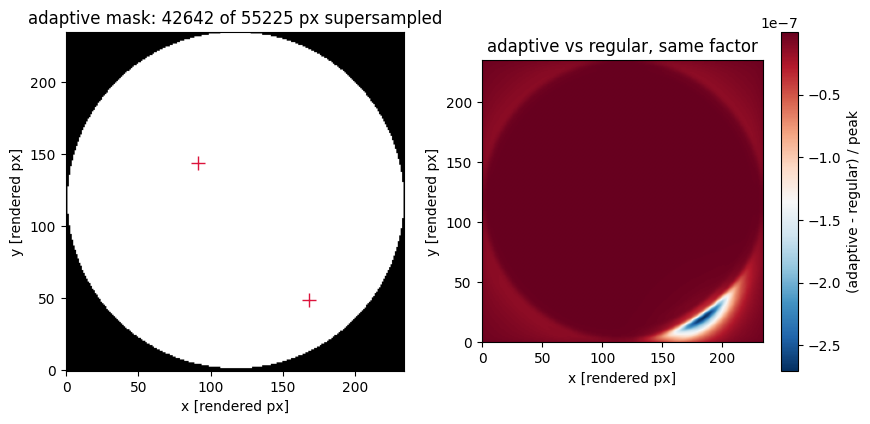

adaptive vs regular: max |difference| = 2.70e-07 of peak


In [21]:
adaptive = SyntheticImage(strong_lens, roman, band, fov_arcsec=fov_arcsec,
                          instrument_params=instrument_params,
                          kwargs_numerics={'supersampling_factor': 3, 'compute_mode': 'adaptive'},
                          kwargs_psf=kwargs_psf, oversample=oversample)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
axes[0].imshow(adaptive.supersampled_indexes, cmap='binary_r')
axes[0].plot(image_x, image_y, ls='none', marker='+', color='crimson', ms=10)
axes[0].set_title(f'adaptive mask: {adaptive.supersampled_indexes.sum()} of '
                  f'{adaptive.supersampled_indexes.size} px supersampled')

diff = adaptive.data - synthetic_image.data
im = axes[1].imshow(diff / synthetic_image.data.max(), cmap='RdBu_r',
                    # vmin=-1e-3, vmax=1e-3
                    )
plt.colorbar(im, ax=axes[1], label='(adaptive - regular) / peak')
axes[1].set_title('adaptive vs regular, same factor')
for ax in axes:
    ax.set_xlabel('x [rendered px]')
    ax.set_ylabel('y [rendered px]')
plt.show()

print(f'adaptive vs regular: max |difference| = {np.abs(diff).max() / synthetic_image.data.max():.2e} of peak')

The mask is a padded annulus containing the image positions; outside it, the scene is smooth
enough that one sample per subpixel is indistinguishable from nine. The saving is real on
the production 455x455 grid — but note that the mask is cached into the *caller's*
`kwargs_numerics` dict, so reusing one dict across different grid sizes silently reuses the
wrong mask. Build a fresh dict per construction.

Now the factor itself. Render a ladder of `supersampling_factor`s at the detector pixel
scale (`oversample=1`) where its meaning is the conventional one, and compare against the
largest.

In [22]:
factors = [1, 2, 3, 5, 9]
native_kwargs_psf = lenstronomy_util.get_pixel_psf_kwargs(kernel, psf_oversample, degrade=True)

ladder = {}
for f in factors:
    start = time.time()
    ladder[f] = SyntheticImage(strong_lens, roman, band, fov_arcsec=fov_arcsec,
                               instrument_params=instrument_params,
                               kwargs_numerics={'supersampling_factor': f, 'compute_mode': 'regular'},
                               kwargs_psf=native_kwargs_psf, oversample=1)
    print(f'supersampling_factor {f}: {time.time() - start:5.2f} s')

reference = ladder[max(factors)].data
n_ref = reference.shape[0]
bright = reference > 0.01 * reference.max()  # fainter pixels have errors dominated by the sky tail

# split the metric: the deflector's Sersic cusp and the arc converge quite differently
yy_ref, xx_ref = np.mgrid[:n_ref, :n_ref] - n_ref // 2
core = np.hypot(xx_ref, yy_ref) < 4
arc = bright & ~core

print(f'{"factor":>7}  {"median, arc":>12}  {"max/peak, arc":>14}  '
      f'{"median, all":>12}  {"peak ratio":>11}')
for f in factors[:-1]:
    d = ladder[f].data - reference
    print(f'{f:>7}  {np.median(np.abs(d[arc]) / reference[arc]):>12.5f}  '
          f'{np.abs(d[arc]).max() / reference.max():>14.5f}  '
          f'{np.median(np.abs(d[bright]) / reference[bright]):>12.5f}  '
          f'{ladder[f].data.max() / reference.max():>11.5f}')

2026-07-29 15:19:30 INFO     Scene size: 5.17 arcsec, 47 pixels at pixel scale 0.11 arcsec/pix
/nfshome/bwedig/mejiro/mejiro/synthetic_image.py:243: UserWarning: Supersampling factor less than 5 may not be sufficient for accurate results, especially when convolving with a non-trivial PSF
  warnings.warn('Supersampling factor less than 5 may not be sufficient for accurate results, especially when convolving with a non-trivial PSF')
2026-07-29 15:19:31 INFO     Synthetic image calculation time: 0.017 s
2026-07-29 15:19:31 INFO     Scene size: 5.17 arcsec, 47 pixels at pixel scale 0.11 arcsec/pix
2026-07-29 15:19:31 INFO     Synthetic image calculation time: 0.018 s
2026-07-29 15:19:31 INFO     Scene size: 5.17 arcsec, 47 pixels at pixel scale 0.11 arcsec/pix
2026-07-29 15:19:31 INFO     Synthetic image calculation time: 0.019 s
2026-07-29 15:19:31 INFO     Scene size: 5.17 arcsec, 47 pixels at pixel scale 0.11 arcsec/pix
2026-07-29 15:19:31 INFO     Synthetic image calculation time: 0.02

supersampling_factor 1:  0.02 s
supersampling_factor 2:  0.02 s
supersampling_factor 3:  0.02 s
supersampling_factor 5:  0.02 s
supersampling_factor 9:  0.07 s
 factor   median, arc   max/peak, arc   median, all   peak ratio
      1       0.01576         0.00539       0.01600      1.95740
      2       0.00291         0.00176       0.00305      0.93463
      3       0.00094         0.00045       0.00098      0.98579
      5       0.00059         0.00011       0.00063      0.98006


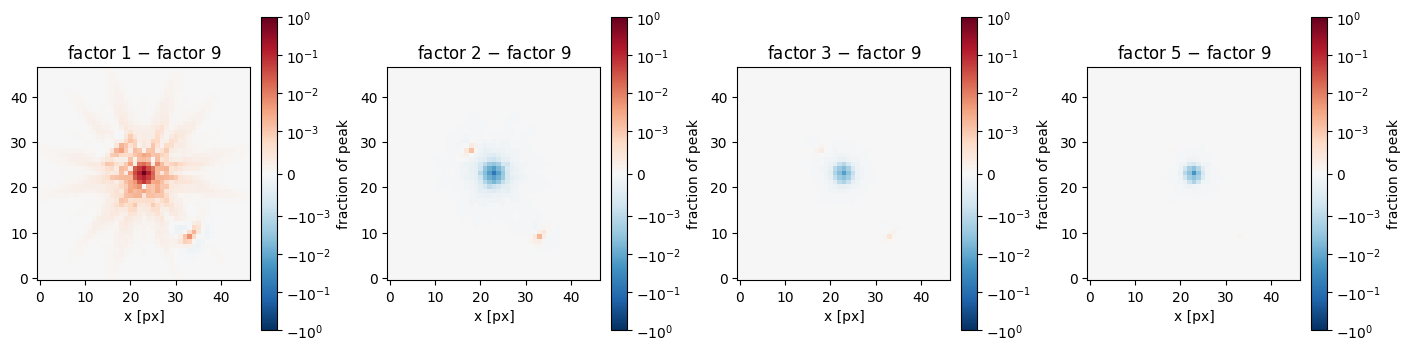

In [24]:
fig, axes = plt.subplots(1, len(factors) - 1, figsize=(14, 3.4), constrained_layout=True)
for ax, f in zip(axes, factors[:-1]):
    d = (ladder[f].data - reference) / reference.max()
    # a symmetric log scale: the deflector core is off by ~100% of peak at factor 1 while the
    # arc is off by a fraction of a percent, and both are worth seeing
    im = ax.imshow(d, cmap='RdBu_r', norm=SymLogNorm(linthresh=1e-3, vmin=-1, vmax=1))
    plt.colorbar(im, ax=ax, label='fraction of peak')
    ax.set_title(f'factor {f} $-$ factor {max(factors)}')
    ax.set_xlabel('x [px]')
plt.show()

The residual traces the arc and the deflector core — exactly the sub-pixel structure a
single sample per pixel cannot see. On the arc the convergence is clean and monotonic: a
few percent of peak at factor 1, a hundredth of a percent by factor 5. This is why
`SyntheticImage` warns below factor 5 at `oversample=1`.

The **peak ratio** column does not converge nearly as tidily, and it is worth understanding
why. The deflector is a Sersic $n = 4$ centred exactly on a pixel centre, and its central
surface brightness is enormous — $\exp(b_4) \approx 2 \times 10^3$ times the value at
$R_e$. An *odd* supersampling factor puts one subpixel sample exactly at $r = 0$ and hands
that one enormous value a $1/N^2$ share of the pixel; an even factor never samples $r = 0$
at all. So the central pixel alternates between over- and under-estimating as the factor
steps, and only settles once $N$ is large enough that the $r = 0$ sample carries negligible
weight. Nothing is wrong — it is a genuinely hard integral, and it is one of the two reasons
section 8 measures convergence on the *binned* image against the *substructure* signal
rather than on a peak pixel.

## 5. The PSF

Roman's PSF is field-dependent: it changes across an SCA and between SCAs. mejiro asks STPSF
for the kernel at the system's detector position and uses that one. Two positions on SCA 01,
same band:

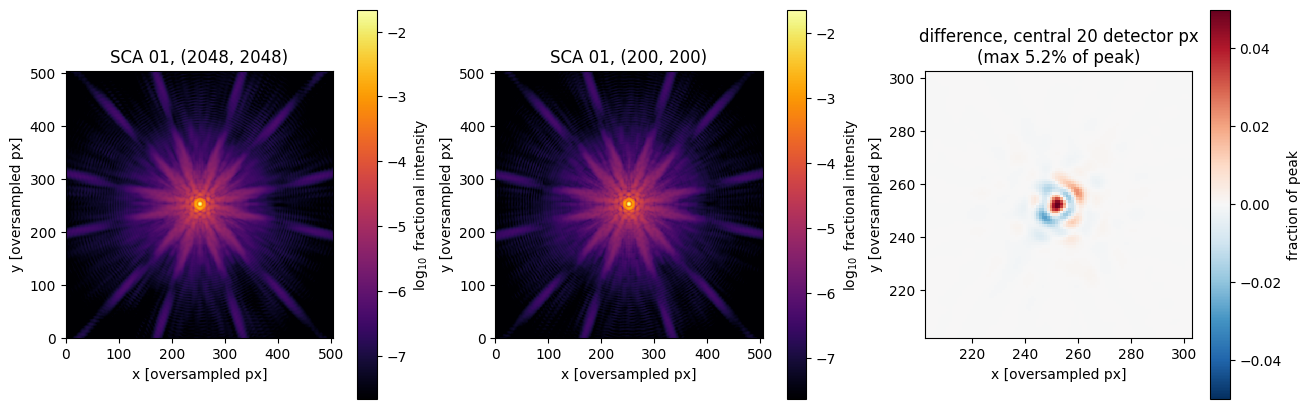

In [17]:
kernel_corner = np.load(os.path.join(TEST_DATA, f'{band}_1_200_200_5_101.npy'))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (title, k) in zip(axes, [('SCA 01, (2048, 2048)', kernel),
                                 ('SCA 01, (200, 200)', kernel_corner)]):
    im = ax.imshow(np.log10(k), cmap='inferno', vmin=np.log10(k.max()) - 6, vmax=np.log10(k.max()))
    plt.colorbar(im, ax=ax, label=r'$\log_{10}$ fractional intensity')
    ax.set_title(title)

d = kernel_corner / kernel_corner.sum() - kernel / kernel.sum()
d_frac = d / (kernel / kernel.sum()).max()
zoom = slice(kernel.shape[0] // 2 - 50, kernel.shape[0] // 2 + 51)  # the core, where it differs
im = axes[2].imshow(d_frac[zoom, zoom], cmap='RdBu_r', vmin=-0.05, vmax=0.05,
                    extent=[zoom.start, zoom.stop, zoom.start, zoom.stop])
plt.colorbar(im, ax=axes[2], label='fraction of peak')
axes[2].set_title(f'difference, central 20 detector px\n(max {np.abs(d_frac).max():.1%} of peak)')
for ax in axes:
    ax.set_xlabel('x [oversampled px]')
    ax.set_ylabel('y [oversampled px]')
plt.show()

A few percent of peak, from moving a third of the way across one detector. That is far
larger than the substructure signal these datasets exist to measure, which is why the
pipeline pins the detector position per system (deterministically — it used to be an
unseeded `random.choice`, see
[docs/step04_oversampled_rendering.md](../docs/step04_oversampled_rendering.md)) and why
every comparison in this notebook holds it fixed.

### Roman is undersampled

At $\lambda = 1.29\ \mu\mathrm{m}$ and $D = 2.36$ m, the diffraction scale is
$\lambda / D \approx 0.113$ arcsec. Nyquist sampling of that needs ~0.056 arcsec/px. Roman
WFI has 0.11 arcsec/px — about a factor of two too coarse. **This single fact drives most of
the rest of this notebook**: it is why the detector pixel response is not a small
correction, why the sub-pixel phase matters, and why a shift cannot be applied at detector
resolution.

In [25]:
wavelength_um = 1.29
diameter_m = 2.36
lam_over_d = np.degrees(wavelength_um * 1e-6 / diameter_m) * 3600
print(f'lambda/D at {wavelength_um} um: {lam_over_d:.4f} arcsec')
print(f'Nyquist pixel scale:          {lam_over_d / 2:.4f} arcsec/px')
print(f'Roman WFI pixel scale:        {pixel_scale:.4f} arcsec/px  '
      f'({pixel_scale / (lam_over_d / 2):.2f}x coarser than Nyquist)')
print(f'kernel at oversample 5:       {pixel_scale / 5:.4f} arcsec/px  '
      f'({(lam_over_d / 2) / (pixel_scale / 5):.2f}x finer than Nyquist)')

lambda/D at 1.29 um: 0.1127 arcsec
Nyquist pixel scale:          0.0564 arcsec/px
Roman WFI pixel scale:        0.1100 arcsec/px  (1.95x coarser than Nyquist)
kernel at oversample 5:       0.0220 arcsec/px  (2.56x finer than Nyquist)


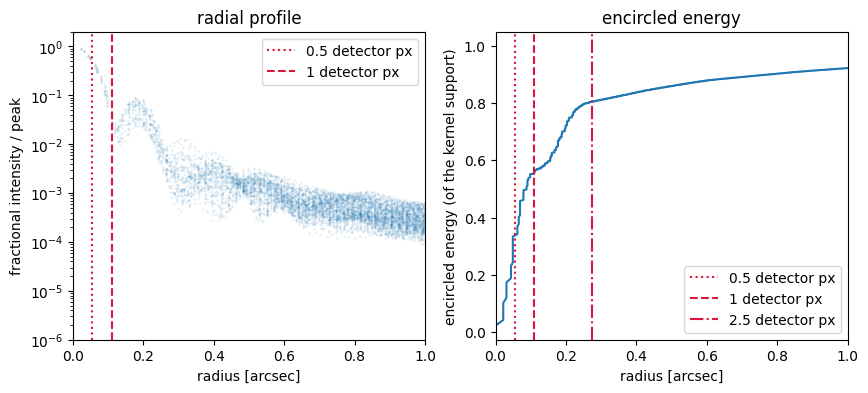

34.2% of the kernel energy falls within half a detector pixel of the centre


In [26]:
# radial profile and encircled energy of the oversampled kernel
n = kernel.shape[0]
yy, xx = np.mgrid[:n, :n] - (n - 1) / 2
r_px = np.hypot(xx, yy) / psf_oversample  # in detector pixels
r_arcsec = r_px * pixel_scale

order = np.argsort(r_arcsec.ravel())
ee = np.cumsum(kernel.ravel()[order]) / kernel.sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(r_arcsec.ravel()[order], kernel.ravel()[order] / kernel.max(),
             ls='none', marker='.', ms=0.5, alpha=0.3)
axes[0].set_yscale('log')
axes[0].set_xlim(0, 1.0)
axes[0].set_ylim(1e-6, 2)
for k, ls in [(0.5, ':'), (1.0, '--')]:
    axes[0].axvline(k * pixel_scale, color='crimson', ls=ls,
                    label=f'{k:g} detector px')
axes[0].set_xlabel('radius [arcsec]')
axes[0].set_ylabel('fractional intensity / peak')
axes[0].set_title('radial profile')
axes[0].legend()

axes[1].plot(r_arcsec.ravel()[order], ee)
for k, ls in [(0.5, ':'), (1.0, '--'), (2.5, '-.')]:
    axes[1].axvline(k * pixel_scale, color='crimson', ls=ls, label=f'{k:g} detector px')
axes[1].set_xlim(0, 1.0)
axes[1].set_xlabel('radius [arcsec]')
axes[1].set_ylabel('encircled energy (of the kernel support)')
axes[1].set_title('encircled energy')
axes[1].legend()
plt.show()

half_pix = ee[np.searchsorted(r_arcsec.ravel()[order], 0.5 * pixel_scale)]
print(f'{half_pix:.1%} of the kernel energy falls within half a detector pixel of the centre')

## 6. The detector pixel response

A detector pixel does not sample the sky, it **integrates** over its own area. Writing $P$
for the 0.11 arcsec top-hat, a real detector records

$$(S \otimes K) \otimes P$$

where $S$ is the surface brightness on the sky and $K$ the optical PSF. Exactly one $P$.

### What lenstronomy does with an oversampled kernel

`get_pixel_psf_kwargs(kernel, 5)` hands lenstronomy a kernel at 5x resolution together with
`point_source_supersampling_factor=5`. lenstronomy's `PSF` class then derives the kernel it
will actually convolve with via `kernel_util.degrade_kernel` — **an exact 5x5 box average**.

A 5x5 box sum at 0.022 arcsec/px *is* the 0.11 arcsec pixel response. So the degraded
kernel is $K \otimes P$, and convolving it with a scene that was itself built by binning
supersampled surface brightness to 0.11 arcsec/px (also a $P$) gives

$$(S \otimes P) \otimes (K \otimes P)$$

One $P$ too many. This is not a subtlety of implementation; it is measurable directly on the
kernel, as one extra box variance in the second moment:

$$\sigma^2\big(\mathrm{degrade}(K, N)\big) = \frac{\sigma^2(K)}{N^2} + \frac{N^2 - 1}{12 N^2}$$

In [27]:
from lenstronomy.Data.psf import PSF

degraded = PSF(**lenstronomy_util.get_pixel_psf_kwargs(kernel, psf_oversample)).kernel_point_source
as_is = PSF(**lenstronomy_util.get_pixel_psf_kwargs(kernel, psf_oversample, degrade=False)).kernel_point_source

print(f'degrade=True  -> lenstronomy convolves with {degraded.shape} (detector resolution)')
print(f'degrade=False -> lenstronomy convolves with {as_is.shape} (as supplied)')
assert np.allclose(as_is, kernel)


def block_sum(a, ov):
    """The detector pixel integral: sum each ov x ov block."""
    n = a.shape[0] // ov
    return a.reshape(n, ov, n, ov).sum(3).sum(1)


# the degraded kernel is not merely *like* a pixel integral of the kernel, it is one
print(f'\ndegrade(K, 5) == block_sum(K, 5): {np.allclose(degraded, block_sum(kernel, psf_oversample))} '
      f'(max difference {np.abs(degraded - block_sum(kernel, psf_oversample)).max():.1e})')


def second_moment(k):
    m = k.shape[0]
    _, x = np.mgrid[:m, :m] - m // 2
    w = k / k.sum()
    return (w * x ** 2).sum()


box_variance = (psf_oversample ** 2 - 1) / 12 / psf_oversample ** 2
predicted = second_moment(kernel) / psf_oversample ** 2 + box_variance
print(f'\nsecond moment of degrade(K, 5): {second_moment(degraded):.6f} detector px^2')
print(f'sigma^2(K)/25 + box variance:   {predicted:.6f} detector px^2')
print(f'agreement: {abs(second_moment(degraded) - predicted) / predicted:.2e} relative')
print(f'(the box variance alone is {box_variance:.6f} detector px^2)')

degrade=True  -> lenstronomy convolves with (101, 101) (detector resolution)
degrade=False -> lenstronomy convolves with (505, 505) (as supplied)

degrade(K, 5) == block_sum(K, 5): True (max difference 2.1e-17)

second moment of degrade(K, 5): 21.298406 detector px^2
sigma^2(K)/25 + box variance:   21.314209 detector px^2
agreement: 7.41e-04 relative
(the box variance alone is 0.080000 detector px^2)


### How much does the double pixel response cost?

To attribute the difference to the pixel response *alone*, both paths have to start from the
same surface brightness. So: render one scene on the fine grid with **no** PSF at all, then
take it down the two routes.

```
old:  bin to native, then convolve with degrade(K)   ->  (S (x) P) (x) (K (x) P)
new:  convolve with K on the fine grid, then bin     ->  (S (x) K) (x) P
```

A Sersic $n = 4$, $R_e = 0.35$ arcsec — a plain deflector, no lensing — keeps the scene as
simple as possible.

In [28]:
from scipy.signal import fftconvolve

from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Util import util as lenstronomy_grid_util


def sersic_scene(n_native=91, n_sersic=4.0, r_sersic=0.35, supersampling_factor=3):
    """An unconvolved Sersic sampled at pixel_scale / 5, in counts/px of the fine grid."""
    scale = pixel_scale / oversample
    num_pix = n_native * oversample
    _, _, ra0, dec0, _, _, mpix2coord, _ = lenstronomy_grid_util.make_grid_with_coordtransform(
        numPix=num_pix, deltapix=scale, subgrid_res=1, left_lower=False, inverse=False)
    pixel_grid = PixelGrid(nx=num_pix, ny=num_pix, ra_at_xy_0=ra0, dec_at_xy_0=dec0,
                           transform_pix2angle=mpix2coord)
    model = ImageModel(data_class=pixel_grid, psf_class=PSF(psf_type='NONE'),
                       lens_light_model_class=LightModel(['SERSIC_ELLIPSE']),
                       kwargs_numerics={'supersampling_factor': supersampling_factor,
                                        'compute_mode': 'regular'})
    kwargs = [{'amp': 1.0, 'R_sersic': r_sersic, 'n_sersic': n_sersic, 'e1': 0.05, 'e2': -0.03,
               'center_x': 0.0, 'center_y': 0.0}]
    return np.asarray(model.image(kwargs_lens_light=kwargs, unconvolved=True), dtype=np.float64)


def two_paths(scene_fine):
    old = fftconvolve(bin_to_native(scene_fine, oversample), degraded, mode='same')
    new = bin_to_native(fftconvolve(scene_fine, kernel, mode='same'), oversample)
    return old, new


print(f'{"scene":<26} {"flux ratio":>11} {"peak ratio":>11} {"max |d|/peak":>13} {"median frac err":>16}')
for label, n_sersic, r_sersic in [('Sersic n=4, Re=0.35"', 4.0, 0.35),
                                  ('Sersic n=1, Re=0.20"', 1.0, 0.20),
                                  ('Sersic n=1, Re=0.60"', 1.0, 0.60)]:
    old, new = two_paths(sersic_scene(n_sersic=n_sersic, r_sersic=r_sersic))
    m = new > 0.01 * new.max()
    print(f'{label:<26} {old.sum() / new.sum():>11.6f} {old.max() / new.max():>11.4f} '
          f'{np.abs(old - new).max() / new.max():>13.2%} '
          f'{np.median(np.abs(old - new)[m] / new[m]):>16.2%}')

scene = sersic_scene()
old_path, new_path = two_paths(scene)
d = old_path - new_path

scene                       flux ratio  peak ratio  max |d|/peak  median frac err
Sersic n=4, Re=0.35"          1.000023      1.0446         4.46%            0.35%
Sersic n=1, Re=0.20"          0.999999      1.0036         1.41%            1.30%
Sersic n=1, Re=0.60"          1.000000      0.9961         0.73%            0.17%


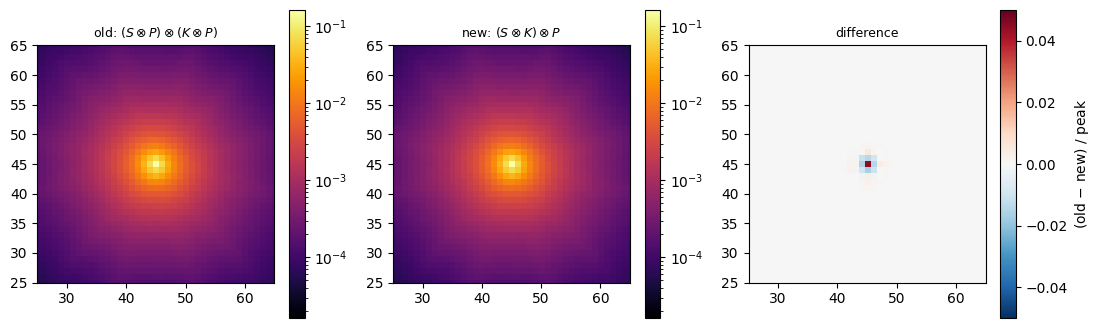

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
norm = LogNorm(vmin=new_path.max() * 1e-4, vmax=new_path.max())
for ax, (title, arr) in zip(axes, [(r'old: $(S \otimes P) \otimes (K \otimes P)$', old_path),
                                   (r'new: $(S \otimes K) \otimes P$', new_path)]):
    im = ax.imshow(arr, norm=norm, cmap='inferno')
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=9)
im = axes[2].imshow(d / new_path.max(), cmap='RdBu_r', vmin=-0.05, vmax=0.05)
plt.colorbar(im, ax=axes[2], label='(old $-$ new) / peak')
axes[2].set_title('difference', fontsize=9)
for ax in axes:
    ax.set_xlim(25, 65)
    ax.set_ylim(25, 65)
plt.show()

A few percent of peak, concentrated on the core, with total flux conserved to a few parts in
$10^5$ — the signature of a redistribution rather than a flux error. It is the same sign
and magnitude the docs report for real substructured rung-1 systems (new peak 0.6-3.5%
lower than old).

### The degeneracy that hid it

For a point source sitting exactly at a pixel centre the two paths agree **exactly**: there
$S \otimes P$ is still a single pixel, and `degrade(K)` and a phase-0 `bin_to_native(K)` are
the same block sum. A point-source test therefore shows nothing at all.

Move the same point source a fraction of a pixel and they diverge violently — because at
detector resolution the first $P$ has already quantized the source position onto the pixel
grid, so the old path's answer does not depend on sub-pixel position at all. That is the
sampling face of the same defect, and it is exactly what section 7 is about.

In [30]:
n_native = 91
fine = n_native * oversample


def point_at(sub_px):
    """A delta displaced `sub_px` detector pixels from a pixel centre, on the fine grid."""
    p = np.zeros((fine, fine))
    p[fine // 2, fine // 2 + int(round(sub_px * oversample))] = 1.0
    return p


for sub_px in (0.0, 0.2, 0.4):
    old, new = two_paths(point_at(sub_px))
    print(f'point source {sub_px:.1f} px off a pixel centre: '
          f'max |difference| {np.abs(old - new).max() / new.max():>9.2e} of peak, '
          f'peak ratio {old.max() / new.max():.4f}')

point source 0.0 px off a pixel centre: max |difference|  1.52e-16 of peak, peak ratio 1.0000
point source 0.2 px off a pixel centre: max |difference|  1.62e-01 of peak, peak ratio 1.0841
point source 0.4 px off a pixel centre: max |difference|  5.03e-01 of peak, peak ratio 1.3724


### Not the only thing that changed

One caution before moving on. Switching a config from `oversample: 1` to `oversample: 5`
does more than fix the pixel response: it also ray-shoots the surface brightness on a much
finer grid (0.0044 arcsec vs 0.022 arcsec for the rung-1 settings), which integrates a cuspy
deflector far more accurately. Run the two configs end to end and both effects are in the
difference, with the sampling one dominating:

In [31]:
def render_config(oversample_, supersampling_factor):
    si = SyntheticImage(SampleGG(), roman, band, fov_arcsec=fov_arcsec,
                        instrument_params=instrument_params,
                        kwargs_numerics={'supersampling_factor': supersampling_factor,
                                         'compute_mode': 'regular'},
                        kwargs_psf=lenstronomy_util.get_pixel_psf_kwargs(
                            kernel, psf_oversample, degrade=(oversample_ == 1)),
                        oversample=oversample_)
    return bin_to_native(np.asarray(si.data, dtype=np.float64), oversample_)


old_config = render_config(1, 5)   # what the pipeline used to ship
new_config = render_config(5, 3)   # what it ships now
m = new_config > 0.01 * new_config.max()
print(f'end to end, old config vs new config:')
print(f'  peak ratio        {old_config.max() / new_config.max():.4f}')
print(f'  flux ratio        {old_config.sum() / new_config.sum():.4f}')
print(f'  max |d| / peak    {np.abs(old_config - new_config).max() / new_config.max():.1%}')
print(f'  median frac err   {np.median(np.abs(old_config - new_config)[m] / new_config[m]):.1%}')
print('\n(compare the isolated pixel-response numbers in the table above: most of this is the '
      'finer\nsurface-brightness sampling, not the pixel response. The two are separable only '
      'by holding\nthe scene fixed, which is what two_paths() does.)')

2026-07-29 18:36:58 INFO     Scene size: 5.17 arcsec, 47 pixels at pixel scale 0.11 arcsec/pix
2026-07-29 18:36:58 INFO     Synthetic image calculation time: 0.024 s
2026-07-29 18:36:58 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix
2026-07-29 18:36:59 INFO     Synthetic image calculation time: 0.185 s


end to end, old config vs new config:
  peak ratio        1.0260
  flux ratio        0.9978
  max |d| / peak    3.7%
  median frac err   0.2%

(compare the isolated pixel-response numbers in the table above: most of this is the finer
surface-brightness sampling, not the pixel response. The two are separable only by holding
the scene fixed, which is what two_paths() does.)


### The fix

`SyntheticImage(oversample=N)` renders at `pixel_scale / N` and uses the kernel as-is. The
saved array is then **not** a detector image: it is the PSF-convolved scene, sampled finely,
with the pixel integral still outstanding. `_05_romanisim` applies it — once, in the right
place, and at the right sub-pixel phase.

The class refuses to let the two drift apart:

In [32]:
try:
    SyntheticImage(strong_lens, roman, band, fov_arcsec=fov_arcsec,
                   instrument_params=instrument_params,
                   kwargs_numerics={'supersampling_factor': 3, 'compute_mode': 'regular'},
                   kwargs_psf=native_kwargs_psf,  # degrade=True: lenstronomy would box-average it
                   oversample=5)
except ValueError as e:
    print(f'ValueError: {e}')

2026-07-29 18:37:04 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix


ValueError: oversample=5 requires a PSF kernel already at the oversampled resolution with point_source_supersampling_factor=1, got 5. Build kwargs_psf with get_pixel_psf_kwargs(..., degrade=False).


The `oversample` value travels with the data. It rides in the lightweight `.npz` metadata
(`schema_version` 2) alongside `pixel_scale` and `num_pix`, so step 05 derives the binning
factor from the file itself rather than from a config that could have moved on. Version-1
files still load and report `oversample = 1`; they describe valid detector-resolution data.

In [33]:
# The lightweight metadata records a handful of scalars that pipeline lenses carry from the
# survey simulation. SampleGG is hand-written and has none of them, so supply them here.
magnification = 4.0
strong_lens.physical_params['lens_velocity_dispersion'] = 250.0
strong_lens.physical_params['magnification'] = magnification
strong_lens.physical_params['magnitudes']['lensed_source'] = {
    b: m - 2.5 * np.log10(magnification)
    for b, m in strong_lens.physical_params['magnitudes']['source'].items()
}

tmp_npz = os.path.join(os.environ.get('TMPDIR', '/tmp'), 'demo_synthetic_image.npz')
synthetic_image.save_lightweight(tmp_npz)
reloaded = util.load_synthetic_image(tmp_npz)
print(f'{type(reloaded).__name__}: {reloaded.data.shape} at {reloaded.pixel_scale:.4f} arcsec/px, '
      f'oversample {reloaded.oversample}')
print(f'  native: {reloaded.native_num_pix} px at {reloaded.native_pixel_scale:.4f} arcsec/px')
print(f'  size on disk: {os.path.getsize(tmp_npz) / 1e6:.2f} MB')
os.remove(tmp_npz)

LightweightSyntheticImage: (235, 235) at 0.0220 arcsec/px, oversample 5
  native: 47 px at 0.1100 arcsec/px
  size on disk: 0.22 MB


## 7. `bin_to_native`: the pixel integral, at a sub-pixel phase

`mejiro.pipeline._05_romanisim.bin_to_native(tile, oversample, frac_x, frac_y)` is the whole
of the missing step:

1. displace the oversampled scene by `(frac_x, frac_y)` **detector** pixels, with a Fourier
   phase ramp;
2. sum each `oversample x oversample` block.

At zero phase it is exactly the block sum and nothing else — no interpolation, bit for bit.

zero phase == plain block sum: exact
phase (+0.300, -0.200): flux ratio 1.000000000000000
phase (+0.500, +0.500): flux ratio 1.000000000000000
phase (-0.500, +0.017): flux ratio 1.000000000000000
shift of 1/5 px vs np.roll: max error 1.94e-16 of peak
shift of 2/5 px vs np.roll: max error 2.09e-16 of peak
shift of -3/5 px vs np.roll: max error 1.04e-16 of peak


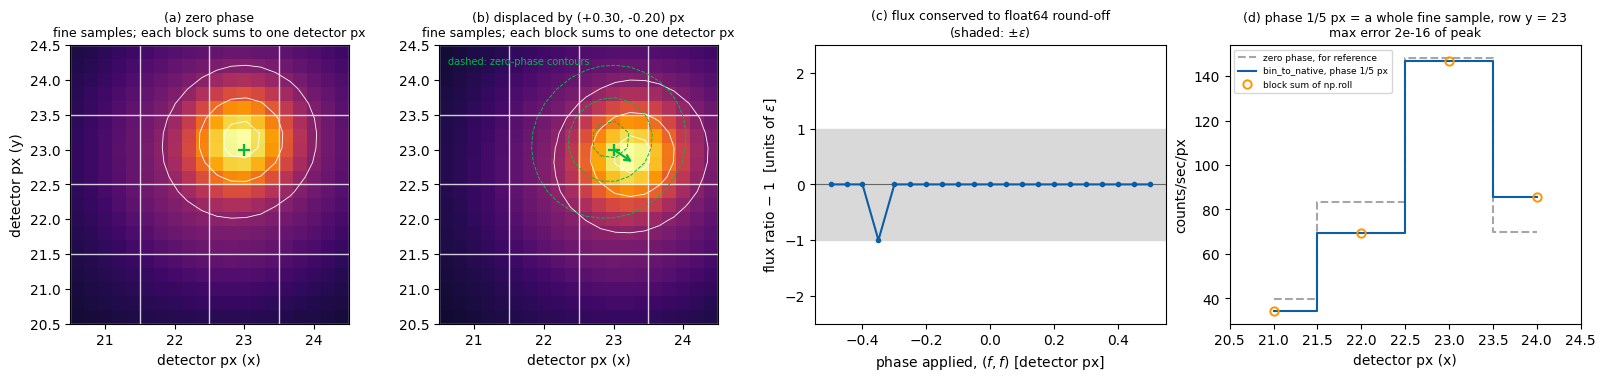

In [36]:
tile = np.asarray(synthetic_image.data, dtype=np.float64)

assert np.array_equal(bin_to_native(tile, oversample), block_sum(tile, oversample))
print('zero phase == plain block sum: exact')

for fx, fy in [(0.3, -0.2), (0.5, 0.5), (-0.5, 0.017)]:
    out = bin_to_native(tile, oversample, fx, fy)
    print(f'phase ({fx:+.3f}, {fy:+.3f}): flux ratio {out.sum() / tile.sum():.15f}')

# a shift of k/oversample detector px is a whole number of fine samples, so it must reproduce
# an exact roll -- the check that the interpolation introduces nothing of its own
for k in (1, 2, -3):
    got = bin_to_native(tile, oversample, k / oversample, 0.0)
    expected = block_sum(np.roll(tile, k, axis=1), oversample)
    print(f'shift of {k}/{oversample} px vs np.roll: max error '
          f'{np.abs(got - expected).max() / expected.max():.2e} of peak')

from scipy.ndimage import fourier_shift

base = bin_to_native(tile, oversample)
frac_x, frac_y = 0.3, -0.2


def displace(t, dx, dy):
    """Step 1 of bin_to_native on its own: the phase ramp, before the block sum."""
    return np.real(np.fft.ifft2(fourier_shift(np.fft.fft2(t), (dy * oversample, dx * oversample))))


# a few detector pixels around the brightest one, cropped on block edges
n_blocks = 4
jy, jx = np.unravel_index(base.argmax(), base.shape)
b0y, b0x = jy - n_blocks // 2, jx - n_blocks // 2
fine_crop = (slice(b0y * oversample, (b0y + n_blocks) * oversample),
             slice(b0x * oversample, (b0x + n_blocks) * oversample))
extent = (b0x - 0.5, b0x + n_blocks - 0.5, b0y - 0.5, b0y + n_blocks - 0.5)
fine_0 = tile[fine_crop]
fine_shifted = displace(tile, frac_x, frac_y)[fine_crop]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.7), constrained_layout=True)
vmax = fine_0.max()
levels = np.array([0.4, 0.7, 0.93]) * vmax

# (a), (b) the block grid is nailed to the detector; the phase ramp slides the scene under it
for ax, arr, title in [(axes[0], fine_0, '(a) zero phase'),
                       (axes[1], fine_shifted, f'(b) displaced by ({frac_x:+.2f}, {frac_y:+.2f}) px')]:
    ax.imshow(arr, cmap='inferno', vmin=0, vmax=vmax, extent=extent)
    ax.contour(arr, levels=levels, colors='w', linewidths=0.6, extent=extent)
    for e in np.arange(n_blocks + 1) - 0.5:
        ax.axvline(b0x + e, color='w', lw=1.0, alpha=0.8)
        ax.axhline(b0y + e, color='w', lw=1.0, alpha=0.8)
    ax.plot(jx, jy, '+', color='#00B945', ms=9, mew=1.6)
    ax.set_xlabel('detector px (x)')
    ax.set_title(f'{title}\nfine samples; each block sums to one detector px', fontsize=9)
axes[0].set_ylabel('detector px (y)')
axes[1].contour(fine_0, levels=levels, colors='#00B945', linewidths=0.7, linestyles='dashed',
                extent=extent)
axes[1].annotate('', xy=(jx + frac_x, jy + frac_y), xytext=(jx, jy),
                 arrowprops=dict(arrowstyle='->', color='#00B945', lw=1.6))
axes[1].text(0.03, 0.96, 'dashed: zero-phase contours', transform=axes[1].transAxes,
             color='#00B945', fontsize=7, va='top')

# (c) the phase ramp leaves the DC term alone, so the block sum conserves flux to round-off
ax = axes[2]
eps = np.finfo(np.float64).eps
sweep = np.linspace(-0.5, 0.5, 21)
dev = [(bin_to_native(tile, oversample, f, f).sum() / tile.sum() - 1.0) / eps for f in sweep]
ax.axhspan(-1, 1, color='0.85', zorder=0)
ax.axhline(0, color='0.4', lw=0.8)
ax.plot(sweep, dev, 'o-', ms=3, color='#0C5DA5')
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('phase applied, $(f, f)$ [detector px]')
ax.set_ylabel(r'flux ratio $-$ 1  [units of $\epsilon$]')
ax.set_title('(c) flux conserved to float64 round-off\n(shaded: $\\pm\\epsilon$)', fontsize=9)

# (d) a phase of k/oversample lands the fine samples back on the grid: an exact roll
ax = axes[3]
k = 1
got = bin_to_native(tile, oversample, k / oversample, 0.0)
rolled = block_sum(np.roll(tile, k, axis=1), oversample)
x = np.arange(b0x, b0x + n_blocks)
cut = slice(b0x, b0x + n_blocks)
ax.step(x, base[jy, cut], where='mid', color='0.65', ls='--', label='zero phase, for reference')
ax.step(x, got[jy, cut], where='mid', color='#0C5DA5',
        label=f'bin_to_native, phase {k}/{oversample} px')
ax.plot(x, rolled[jy, cut], 'o', ms=6, mfc='none', mew=1.4, color='#FF9500',
        label='block sum of np.roll')
ax.set_xlim(extent[0], extent[1])
ax.set_xlabel('detector px (x)')
ax.set_ylabel('counts/sec/px')
ax.set_title(f'(d) phase {k}/{oversample} px = a whole fine sample, row y = {jy}\n'
             f'max error {np.abs(got - rolled).max() / rolled.max():.0e} of peak', fontsize=9)
ax.legend(fontsize=6.5, loc='upper left')
plt.show()

### Why the phase matters

Because Roman is undersampled, how much of the PSF core lands in the peak pixel depends
strongly on where the source sits *within* that pixel. Binning the same scene at a ladder of
phases makes the point:

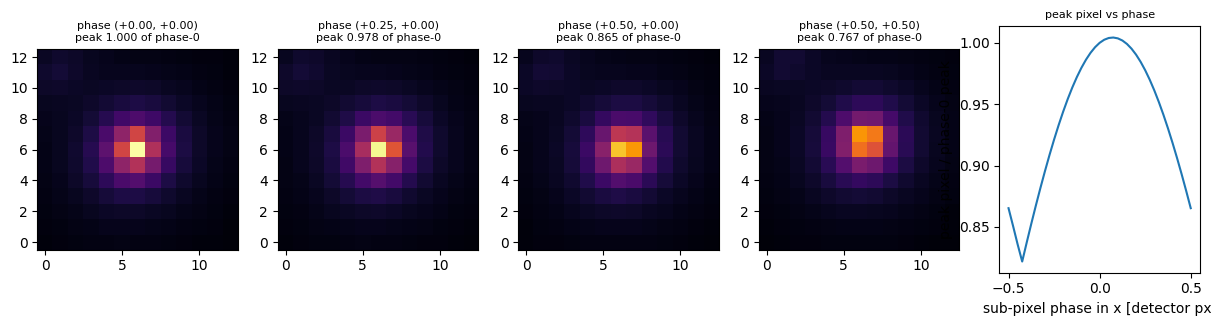

peak pixel varies by 18.2% over the phase range


In [37]:
phases = [(0.0, 0.0), (0.25, 0.0), (0.5, 0.0), (0.5, 0.5)]
fig, axes = plt.subplots(1, len(phases) + 1, figsize=(15, 3.2))
base = bin_to_native(tile, oversample)
crop = slice(base.shape[0] // 2 - 6, base.shape[0] // 2 + 7)

for ax, (fx, fy) in zip(axes, phases):
    binned = bin_to_native(tile, oversample, fx, fy)
    im = ax.imshow(binned[crop, crop], cmap='inferno', vmin=0, vmax=base.max())
    ax.set_title(f'phase ({fx:+.2f}, {fy:+.2f})\npeak {binned.max() / base.max():.3f} of phase-0',
                 fontsize=8)

# peak pixel value across a 1-d sweep of phase
sweep = np.linspace(-0.5, 0.5, 41)
peaks = [bin_to_native(tile, oversample, fx, 0.0).max() / base.max() for fx in sweep]
axes[-1].plot(sweep, peaks)
axes[-1].set_xlabel('sub-pixel phase in x [detector px]')
axes[-1].set_ylabel('peak pixel / phase-0 peak')
axes[-1].set_title('peak pixel vs phase', fontsize=8)
plt.show()

print(f'peak pixel varies by {(max(peaks) - min(peaks)) / max(peaks):.1%} over the phase range')

The maximum of that curve is the phase that centres the source on a pixel — a shade off
zero here only because `SampleGG`'s deflector sits 0.07 px from the grid centre. It is the
single most favourable sampling phase there is, and it was the phase of every system in
every mejiro dataset before this was fixed: measured on 400 real rung-1 step-04 files,
**97.5% had their brightest pixel at the exact centre index**.

The L3 path has a real phase available — each dither's true sky position carries one. The L2
path does not, so it draws a deterministic one per system, keyed on the seed and the lens
name so it is identical in every band and stable across `--resume`:

subpixel_phase(42, "lens_00000001") = (-0.20719550270587206, -0.3203273485414684)
same call again:                      (-0.20719550270587206, -0.3203273485414684)
different seed:                       (0.13185548246838152, 0.054509400855749846)


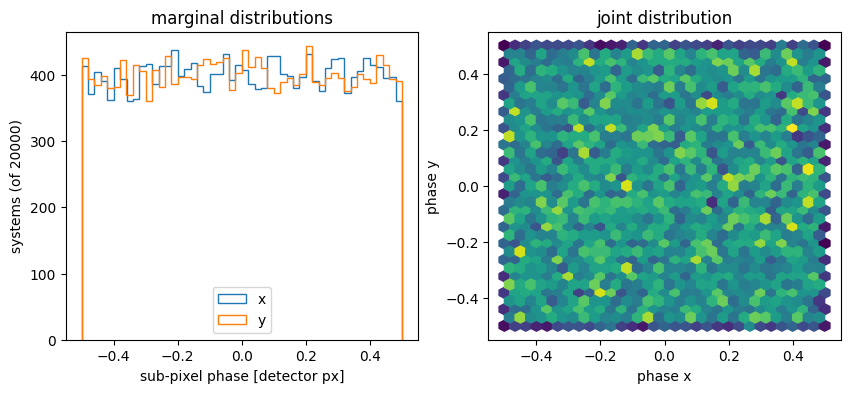

In [38]:
names = [f'lens_{i:08d}' for i in range(20000)]
draws = np.array([subpixel_phase(42, n) for n in names])

print(f'subpixel_phase(42, "lens_00000001") = {subpixel_phase(42, "lens_00000001")}')
print(f'same call again:                      {subpixel_phase(42, "lens_00000001")}')
print(f'different seed:                       {subpixel_phase(43, "lens_00000001")}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(draws[:, 0], bins=50, histtype='step', label='x')
axes[0].hist(draws[:, 1], bins=50, histtype='step', label='y')
axes[0].set_xlabel('sub-pixel phase [detector px]')
axes[0].set_ylabel(f'systems (of {len(names)})')
axes[0].set_title('marginal distributions')
axes[0].legend()
axes[1].hexbin(draws[:, 0], draws[:, 1], gridsize=30)
axes[1].set_xlabel('phase x')
axes[1].set_ylabel('phase y')
axes[1].set_title('joint distribution')
plt.show()

### The phase has to be applied on the oversampled grid

The cheap alternative is to bin first and shift the 47x47 detector-resolution tile with
`scipy.ndimage.shift`. It is wrong at the percent level, and for a reason that is easy to
miss: the native tile is *undersampled*, so the shift theorem does not apply to it and the
interpolation is aliasing-limited exactly at the PSF core.

Measure it against an exact reference — the real STPSF kernel displaced on the oversampled
grid and then binned — over the six SUB6 dither residuals recorded in
[docs/l3_dither_registration.md](../docs/l3_dither_registration.md).

In [39]:
from scipy.ndimage import fourier_shift, shift as ndshift

SUB6_RESIDUALS = [  # (dy, dx) in detector px, measured at the rung-1 pointing
    (0.000, 0.000), (-0.164, -0.167), (0.171, 0.180),
    (0.408, -0.332), (0.247, 0.498), (0.085, 0.330),
]

ov = 5
k = kernel[:(kernel.shape[0] // ov) * ov, :(kernel.shape[0] // ov) * ov].astype(np.float64)
k /= k.sum()
k_native = block_sum(k, ov)


def exact(dy, dx):
    """Reference: displace on the oversampled grid, then bin."""
    return block_sum(np.real(np.fft.ifft2(fourier_shift(np.fft.fft2(k), (dy * ov, dx * ov)))), ov)


def median_err(a, b):
    m = b > 0.01 * b.max()
    return np.median(np.abs(a - b)[m] / b[m])


schemes = {
    'integer placement (no shift at all)': lambda dy, dx: k_native,
    'shift the native tile, cubic spline': lambda dy, dx: ndshift(k_native, (dy, dx), order=3, mode='nearest'),
    'shift the native tile, Fourier': lambda dy, dx: np.real(np.fft.ifft2(
        fourier_shift(np.fft.fft2(k_native), (dy, dx)))),
    'oversample, bin at the nearest 1/5 phase': lambda dy, dx: bin_to_native(
        k, ov, round(dx * ov) / ov, round(dy * ov) / ov),
    'oversample, shift there, then bin': lambda dy, dx: bin_to_native(k, ov, dx, dy),
}

print(f'{"scheme":<42} {"worst single exposure":>22} {"6-dither co-add":>17}')
coadd_exact = np.mean([exact(dy, dx) for dy, dx in SUB6_RESIDUALS], axis=0)
for name, fn in schemes.items():
    per_dither = [median_err(fn(dy, dx), exact(dy, dx)) for dy, dx in SUB6_RESIDUALS]
    coadd = np.mean([fn(dy, dx) for dy, dx in SUB6_RESIDUALS], axis=0)
    print(f'{name:<42} {max(per_dither):>21.1%} {median_err(coadd, coadd_exact):>17.1%}')

scheme                                      worst single exposure   6-dither co-add
integer placement (no shift at all)                        55.8%             18.1%
shift the native tile, cubic spline                        58.8%              9.0%
shift the native tile, Fourier                            142.7%             17.7%
oversample, bin at the nearest 1/5 phase                   13.6%              4.1%
oversample, shift there, then bin                           0.0%              0.0%


Two things fall out of that table. Fourier-shifting the *native* tile is worse than cubic,
because it rings on the aliased power rather than smoothing over it. And oversampling
without a shift is not enough either: at 5x the residual phase error is up to 0.1 px, still
a few percent on the co-add. **The oversampled render and the sub-pixel shift are both
required.**

On a resolved feature the native shift does fine, which is exactly why this is easy to get
wrong — it only fails on the unresolved core:

In [40]:
n_fine = 91 * ov
yy, xx = np.mgrid[:n_fine, :n_fine] - (n_fine - 1) / 2.0
blob = np.exp(-(xx ** 2 + yy ** 2) / (2 * 12.0 ** 2))
blob /= blob.sum()
blob_native = block_sum(blob, ov)

worst = 0.0
for dy, dx in SUB6_RESIDUALS:
    ref = block_sum(np.real(np.fft.ifft2(fourier_shift(np.fft.fft2(blob), (dy * ov, dx * ov)))), ov)
    worst = max(worst, median_err(ndshift(blob_native, (dy, dx), order=3, mode='nearest'), ref))
print(f'resolved Gaussian blob (sigma = 2.4 detector px), native cubic shift: '
      f'{worst:.2%} worst-case median error')
print('(vs several tens of percent on the PSF core above)')

resolved Gaussian blob (sigma = 2.4 detector px), native cubic shift: 0.04% worst-case median error
(vs several tens of percent on the PSF core above)


## 8. Choosing `supersampling_factor` at `oversample > 1`

At `oversample = 5` the grid pixel is already 0.022 arcsec, so `supersampling_factor`
subdivides a subpixel. The conventional "use at least 5" no longer applies, and the right
value has to be chosen against the signal the dataset exists to measure — for the Roman data
challenge, the imprint of dark matter substructure.

That is the measurement `projects/roman_data_challenge/supersampling_convergence.py` makes,
over a sample of real pipeline systems. Here is the same measurement on one system, small
enough to run inline: add a pyHalo CDM realization, render a ladder of factors, bin each to
detector resolution, and compare the numerical error against the substructure signal.

In [41]:
from pyHalo.preset_models import preset_model_from_name

CDM = preset_model_from_name('CDM')
realization = CDM(round(strong_lens.z_lens, 2),
                  round(strong_lens.z_source, 2),
                  sigma_sub=0.055,
                  cone_opening_angle_arcsec=2.5 * strong_lens.get_einstein_radius(),
                  LOS_normalization=0.,
                  log_mlow=7.,
                  log_mhigh=10.,
                  log_m_host=np.log10(strong_lens.get_main_halo_mass()),
                  r_tidal=0.5)

substructured = SampleGG()
substructured.add_realization(realization)
print(f'{len(realization.halos)} halos -> {len(substructured.lens_model_list)} lens model components')

114 halos -> 118 lens model components


In [42]:
sub_factors = [1, 2, 3, 5]
sub_ladder = {}
for f in sub_factors:
    start = time.time()
    si = SyntheticImage(substructured, roman, band, fov_arcsec=fov_arcsec,
                        instrument_params=instrument_params,
                        # a FRESH dict per construction: SyntheticImage caches
                        # supersampled_indexes into the caller's kwargs_numerics
                        kwargs_numerics={'supersampling_factor': f, 'compute_mode': 'regular'},
                        kwargs_psf=kwargs_psf, oversample=oversample)
    sub_ladder[f] = (bin_to_native(np.asarray(si.data, dtype=np.float64), oversample),
                     time.time() - start)
    print(f'supersampling_factor {f}: {sub_ladder[f][1]:6.2f} s')

# the same system without substructure, at the reference factor: the signal to beat
smooth = SyntheticImage(SampleGG(), roman, band, fov_arcsec=fov_arcsec,
                        instrument_params=instrument_params,
                        kwargs_numerics={'supersampling_factor': max(sub_factors),
                                         'compute_mode': 'regular'},
                        kwargs_psf=kwargs_psf, oversample=oversample)
no_sub = bin_to_native(np.asarray(smooth.data, dtype=np.float64), oversample)

2026-07-29 20:28:44 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix
2026-07-29 20:28:45 INFO     Synthetic image calculation time: 0.603 s
2026-07-29 20:28:45 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix


supersampling_factor 1:   0.60 s


2026-07-29 20:28:47 INFO     Synthetic image calculation time: 2.326 s
2026-07-29 20:28:47 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix


supersampling_factor 2:   2.33 s


2026-07-29 20:28:53 INFO     Synthetic image calculation time: 5.477 s
2026-07-29 20:28:53 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix


supersampling_factor 3:   5.48 s


2026-07-29 20:29:13 INFO     Synthetic image calculation time: 20.574 s
2026-07-29 20:29:13 INFO     Scene size: 5.17 arcsec, 235 pixels at pixel scale 0.022 arcsec/pix


supersampling_factor 5:  20.58 s


2026-07-29 20:29:14 INFO     Synthetic image calculation time: 0.443 s


In [43]:
ref = sub_ladder[max(sub_factors)][0]
bright = ref > 0.01 * ref.max()
# the median over all bright pixels is dominated by the deflector core, which substructure
# barely touches; restrict to the brightest decile of the |with - without| difference
signal_diff = np.abs(ref - no_sub)
signal_region = bright & (signal_diff >= np.percentile(signal_diff[bright], 90))
signal_level = np.median(signal_diff[signal_region] / ref[signal_region])

print(f'substructure signal over the pixels that carry it: {signal_level:.2%} median\n')
print(f'{"factor":>7}  {"median |d|/val":>15}  {"max |d|/peak":>13}  {"err/signal":>11}  {"seconds":>8}')
for f in sub_factors[:-1]:
    arr, secs = sub_ladder[f]
    d = arr - ref
    err = np.median(np.abs(d[signal_region]) / ref[signal_region])
    print(f'{f:>7}  {np.median(np.abs(d[bright]) / ref[bright]):>15.5f}  '
          f'{np.abs(d).max() / ref.max():>13.5f}  {err / signal_level:>11.3f}  {secs:>8.2f}')

substructure signal over the pixels that carry it: 11.77% median

 factor   median |d|/val   max |d|/peak   err/signal   seconds
      1          0.00073        0.02092        0.004      0.60
      2          0.00016        0.00469        0.001      2.33
      3          0.00005        0.00114        0.000      5.48


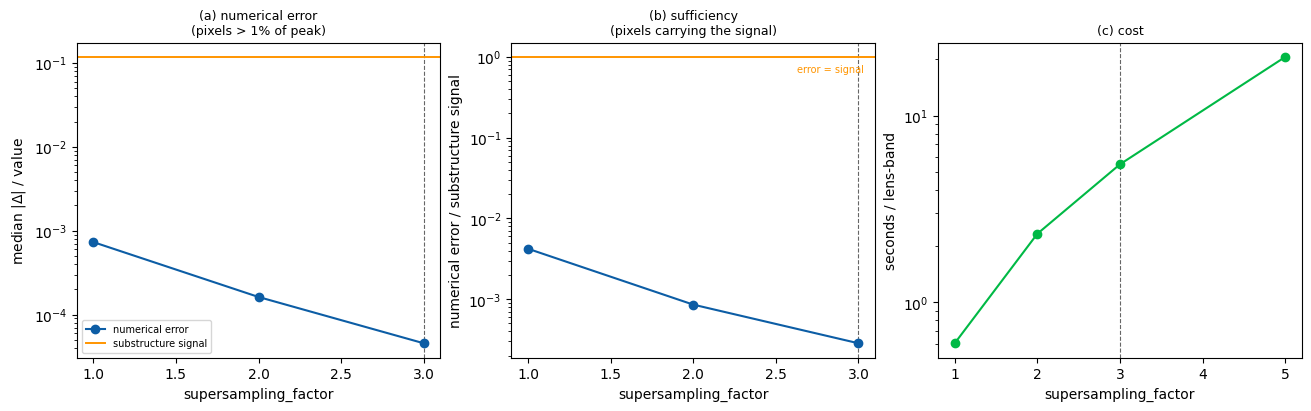

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

ax = axes[0]
errs = [np.median(np.abs(sub_ladder[f][0] - ref)[bright] / ref[bright]) for f in sub_factors[:-1]]
ax.plot(sub_factors[:-1], errs, 'o-', color='#0C5DA5', label='numerical error')
ax.axhline(signal_level, color='#FF9500', lw=1.4, label='substructure signal')
ax.set_yscale('log')
ax.set_xlabel('supersampling_factor')
ax.set_ylabel(r'median $|\Delta|$ / value')
ax.set_title('(a) numerical error\n(pixels > 1% of peak)', fontsize=9)
ax.legend(fontsize=7)

ax = axes[1]
ratios = [np.median(np.abs(sub_ladder[f][0] - ref)[signal_region] / ref[signal_region]) / signal_level
          for f in sub_factors[:-1]]
ax.plot(sub_factors[:-1], ratios, 'o-', color='#0C5DA5')
ax.axhline(1.0, color='#FF9500', lw=1.4)
ax.text(0.97, 0.93, 'error = signal', transform=ax.transAxes, ha='right', va='top',
        fontsize=7, color='#FF9500')
ax.set_yscale('log')
ax.set_xlabel('supersampling_factor')
ax.set_ylabel('numerical error / substructure signal')
ax.set_title('(b) sufficiency\n(pixels carrying the signal)', fontsize=9)

ax = axes[2]
ax.plot(sub_factors, [sub_ladder[f][1] for f in sub_factors], 'o-', color='#00B945')
ax.set_yscale('log')
ax.set_xlabel('supersampling_factor')
ax.set_ylabel('seconds / lens-band')
ax.set_title('(c) cost', fontsize=9)

for ax in axes:
    ax.axvline(3, color='0.4', ls='--', lw=0.8, zorder=0)
plt.show()

The dashed line marks the value the rung-1 configs ship, `supersampling_factor: 3`. The
production study — same three panels, over a sample of real pipeline systems rather than one
analytic one — is:

```
python3 projects/roman_data_challenge/supersampling_convergence.py \
    --config projects/roman_data_challenge/roman_data_challenge_rung_1.yaml \
    --band F129 --factors 1 2 3 5 7 9 --n-lenses 12
```

Two cautions that study exists to enforce, both learned the hard way:

- **Compare after binning.** Detector resolution is all step 05 ever consumes; sub-pixel
  detail that the binning averages away is not error anyone sees.
- **Pin the detector position.** The first attempt at this measurement compared different
  STPSF kernels rather than different factors, because `detector_position` was drawn with an
  unseeded `random.choice`. Section 5 shows how big that confound is.

And read the numbers above carefully, because they do **not** justify the shipped value on
their own: on this system every factor on the ladder sits orders of magnitude below the
substructure signal, so this measurement says factor 1 would do.

That is a property of this system, not a licence. `SampleGG` is an SIE with an analytic
Sersic source, and the realization bolted onto it above is a light one — a few dozen halos
above $10^7 M_\odot$, no line-of-sight population. A rung-1 system carries a deflector fit
to a real galaxy, a COSMOS-Web source image resampled onto the grid, and a CDM realization
down to $10^6 M_\odot$ including line-of-sight halos. Measured on twelve of those, factor 1
leaves 0.11% median / 0.70% max-of-peak against a factor-5 reference and factor 3 leaves
0.002% / 0.14% — and 0.70% of peak is not comfortably below the substructure signal, while
0.14% is.

That gap between what a sample lens says and what real inputs say is exactly why
`supersampling_convergence.py` reads step-03 pickles instead of constructing its own lens.

## What comes next

What we have at this point is exactly what step 04 of the pipeline writes to disk: the
PSF-convolved scene in counts/sec, sampled at `pixel_scale / oversample`, with the detector
pixel integral deliberately not yet applied.

In [46]:
print(f'step-04 product: {synthetic_image.data.shape} at {synthetic_image.pixel_scale:.4f} arcsec/px, '
      f'oversample {synthetic_image.oversample}')
print(f'  -> bins to    {bin_to_native(tile, oversample).shape} at '
      f'{synthetic_image.native_pixel_scale:.4f} arcsec/px')
print(f'  units: counts/sec; total {synthetic_image.get_flux():.2f} '
      f'= {synthetic_image.get_maggies():.4e} maggies')

step-04 product: (235, 235) at 0.0220 arcsec/px, oversample 5
  -> bins to    (47, 47) at 0.1100 arcsec/px
  units: counts/sec; total 4223.49 = 1.2529e-07 maggies


`l2_l3_with_romanisim.ipynb` takes it from here: converting to electrons, tiling many
systems onto a 4088x4088 SCA, running romanisim to get L2 exposures, dithering, and co-adding
with romancal's `MosaicPipeline` to get L3 — including where the sub-pixel phase of section 7
comes from in each case.